# Introduction

This analysis aims to compare the performances of the RF alogrithm and ANN alogrithm on the compound activity/inactivity predictions. 

Dataset used was 1000 randomly chosen models from the original PIDGIN4 no_ortho dataset. 
For each model, the same train-test-split (the test set proportion was 25% and the random state was 123) was applied to ensure that fair comparisioon between the RF and ANN alogrithms.

The following metrics were used to compare the two alogrithms:




# Import data and required libraries

In [1]:
# import required libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [17]:
def retrieve_data (path):
    df = pd.read_csv(path,sep='\t')
    #Retrieve performance measuring metrics
    df['pub_bedroc_ret']=df['pub_bedroc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['pub_roc_ret']=df['pub_roc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['pub_pr_auc_ret']=df['pub_pr_auc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['pub_bs_ret']=df['pub_bs_ret'].str.split(',',expand=True).astype('float').iloc[:,0]

    df['scaf_bedroc_ret']=df['scaf_bedroc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['scaf_roc_ret']=df['scaf_roc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['scaf_pr_auc_ret']=df['scaf_pr_auc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['scaf_bs_ret']=df['scaf_bs_ret'].str.split(',',expand=True).astype('float').iloc[:,0]

    df['tscv_bedroc_ret']=df['tscv_bedroc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['tscv_roc_ret']=df['tscv_roc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['tscv_pr_auc_ret']=df['tscv_pr_auc_ret'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['tscv_bs_ret']=df['tscv_bs_ret'].str.split(',',expand=True).astype('float').iloc[:,0]


    df['train_pc_a']=df['train_pc_a'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['test_pc_a']=df['test_pc_a'].str.split(',',expand=True).astype('float').iloc[:,0]
    # transform the p inactive data: 
    # Before, close to 0 means high confidence (p=0 means it is 100% confident that it is inactive). 
    # After, close to 1 means high confidence.
    df['test_pc_i']=1 - df['test_pc_i'].str.split(',',expand=True).astype('float').iloc[:,0]
    df['train_pc_i']=1 - df['train_pc_i'].str.split(',',expand=True).astype('float').iloc[:,0]

    df.set_index('MODEL_ID',inplace = True)
    measuring_metrics = [
     'test_roc', 'test_prauc', 'test_brier', 'test_bedroc',
       'test_pc_i', 'test_pc_a', 'test_weighted_accuracy', 'test_mcc',
       'test_actives_precision', 'test_actives_recall', 'test_actives_f1',
       'test_inactives_precision', 'test_inactives_recall',
       'test_inactives_f1', 'train_roc', 'train_prauc', 'train_brier',
       'train_bedroc', 'train_pc_i', 'train_pc_a', 'train_weighted_accuracy',
       'train_mcc', 'train_actives_precision', 'train_actives_recall',
       'train_actives_f1', 'train_inactives_precision',
       'train_inactives_recall', 'train_inactives_f1', 'pub_bedroc_ret',
       'pub_roc_ret', 'pub_pr_auc_ret', 'pub_bs_ret',
       'scaf_bedroc_ret', 'scaf_roc_ret', 'scaf_pr_auc_ret', 'scaf_bs_ret',
       'tscv_bedroc_ret', 'tscv_roc_ret', 'tscv_pr_auc_ret',
       'tscv_bs_ret', 'conf_one_class_rate',
       'conf_true_active_rate', 'conf_true_inactive_rate']
    return df[measuring_metrics]

In [18]:
dfANN = retrieve_data('./ANN_training_log_0to99/training_log.txt')
dfRF =retrieve_data('./RF_training_log_0to99/training_log.txt')

# Analysis about different metrics

## Compare the mean of differents metrics from RF and ANN

In [4]:
def plot_avg_metrics(df_list,columns_dic):
    df = pd.concat(df_list,axis=1).rename(columns=columns_dic)
    df.plot.barh(figsize=(8,13))
    plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5))
    return
    

### Compare all the metrics using bar chart

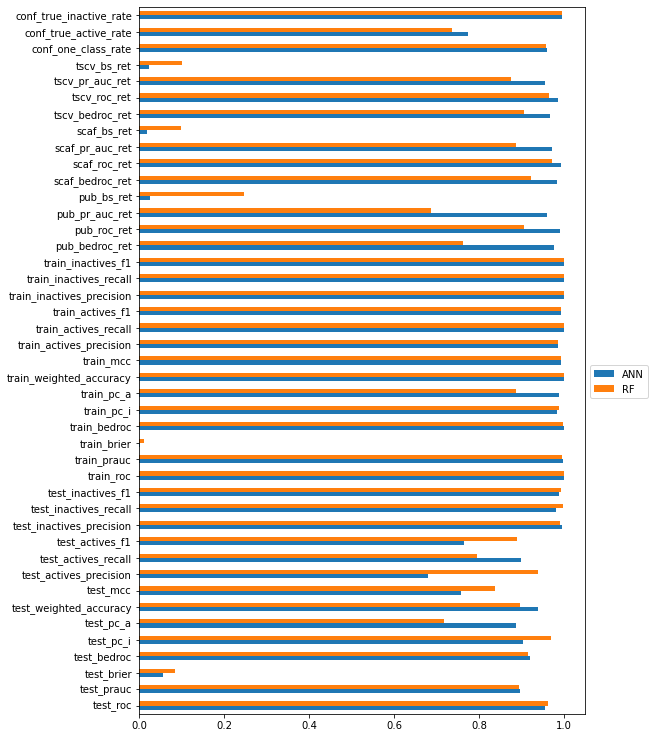

In [5]:
plot_avg_metrics([dfANN.mean(),dfRF.mean()],{0:'ANN',1:'RF'})

### Calculate mean and std of these metrics

In [59]:
from scipy.stats import ttest_ind
_,p = ttest_ind(dfANN,
                dfRF,
                equal_var = False,
                nan_policy = 'omit',axis=0)
p = pd.Series(data = p, index = list(dfANN.mean().index))

isANNBetter = dfANN.mean() > dfRF.mean()

# for brier score, the lower the better
isANNBetter[['tscv_bs_ret','pub_bs_ret',
             'scaf_bs_ret','train_brier','test_brier']] = \
isANNBetter[['tscv_bs_ret','pub_bs_ret',
             'scaf_bs_ret','train_brier','test_brier']].apply(func=lambda x: not x)

change = dfANN.mean()-dfRF.mean()

lst = [dfANN.mean(),dfANN.std(),dfRF.mean(),dfRF.std(),change,
       p,p<0.05,isANNBetter,]
dic = {0:'ANN mean',1:'ANN std',2:'RF mean',3:'RF std',4:'change',
       5:'p test',6:'significant at p=0.05?',7:'isANNBetter?'}
dfMeanMetrics = pd.concat(lst,axis=1).rename(columns=dic)
dfMeanMetrics

,ANN mean,ANN std,RF mean,RF std,change,p test,significant at p=0.05?,isANNBetter?
test_roc,0.955210,0.100539,0.962270,0.098746,-0.007060,6.169363e-01,False,False
test_prauc,0.896690,0.190730,0.893900,0.198976,0.002790,9.194751e-01,False,True
test_brier,0.055780,0.076115,0.083910,0.096057,-0.028130,2.282229e-02,True,True
test_bedroc,0.919630,0.175811,0.915230,0.185439,0.004400,8.634653e-01,False,True
test_pc_i,0.902610,0.065890,0.969950,0.024006,-0.067340,1.099378e-16,True,False
test_pc_a,0.887240,0.171883,0.716780,0.201813,0.170460,9.763094e-10,True,True
test_weighted_accuracy,0.939020,0.095842,0.896410,0.130699,0.042610,9.296343e-03,True,True
test_mcc,0.757660,0.215701,0.836680,0.243379,-0.079020,1.601083e-02,True,False
test_actives_precision,0.679310,0.263105,0.937771,0.158927,-0.258461,2.538649e-14,True,False
test_actives_recall,0.898010,0.186138,0.795390,0.260755,0.102620,1.609249e-03,True,True


metrics to look at
- weighted accuracy
- mcc
- f1
- precision
- recall
- roc (paper)
- conf true active rate
- conf one class rate

From this table, we see that the ANN model performs better than RF generally.

The ANN performs better in cross validation than RF.

ANN performs better at TEST_ACCURACY, TEST_ACTIVES_RECALL, TEST_ACTIVES_F1, TEST_INACTIVES_PRECISION, TEST_INACTIVES_F1.	

There is no improvement on TEST_ACTIVES_PRECISION.

There is a decrease in TEST_INACTIVES_RECALL.

For the following sections, we will focus on precision, recall, f1 score, roc.

In [8]:
# metrics to analyse further
lst = ['test_roc','test_weighted_accuracy','test_mcc','test_actives_precision',
      'test_actives_recall','conf_one_class_rate',
       'conf_true_active_rate', 'conf_true_inactive_rate']
dfANN = dfANN[lst]
dfRF = dfRF[lst]

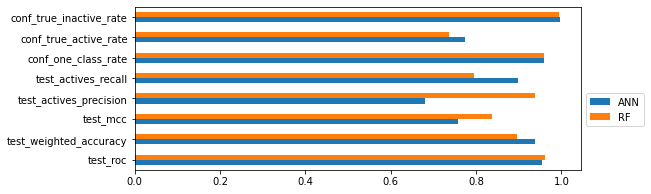

In [12]:
plot_avg_metrics([dfANN.mean(),dfRF.mean()],{0:'ANN',1:'RF'})
fig = plt.gcf()
fig.set_size_inches((8,3))

### Calculate mean and std of these metrics

In [24]:
from scipy.stats import ttest_ind
_,p = ttest_ind(dfANN,
                dfRF,
                equal_var = False,
                nan_policy = 'omit',axis=0)
p = pd.Series(data = p, index = list(dfANN.mean().index))

isANNBetter = dfANN.mean() > dfRF.mean()

change = dfANN.mean()-dfRF.mean()

lst = [dfANN.mean(),dfANN.std(),dfRF.mean(),dfRF.std(),change,
       p,p<0.05,isANNBetter,]
dic = {0:'ANN mean',1:'ANN std',2:'RF mean',3:'RF std',4:'change',
       5:'p test',6:'significant at p=0.05?',7:'isANNBetter?'}
dfMeanMetrics = pd.concat(lst,axis=1).rename(columns=dic)

lst = []
for metric in dfMeanMetrics.index:
    ni = sum((dfANN[metric]>dfRF[metric]).astype(int))
    lst.append(ni*100/len(dfANN))
    
lst = pd.Series(lst,index = dfMeanMetrics.index,name='%improved models')
dfMeanMetrics = dfMeanMetrics.join(lst)
dfMeanMetrics

,ANN mean,ANN std,RF mean,RF std,change,p test,significant at p=0.05?,isANNBetter?,%improved models
test_roc,0.95521,0.100539,0.962270,0.098746,-0.007060,6.169363e-01,False,False,26.0
test_weighted_accuracy,0.93902,0.095842,0.896410,0.130699,0.042610,9.296343e-03,True,True,52.0
test_mcc,0.75766,0.215701,0.836680,0.243379,-0.079020,1.601083e-02,True,False,26.0
test_actives_precision,0.67931,0.263105,0.937771,0.158927,-0.258461,2.538649e-14,True,False,2.0
test_actives_recall,0.89801,0.186138,0.795390,0.260755,0.102620,1.609249e-03,True,True,52.0
conf_one_class_rate,0.96016,0.020026,0.958450,0.018283,0.001710,5.290245e-01,False,True,42.0
conf_true_active_rate,0.77294,0.249382,0.736860,0.422312,0.036080,4.630141e-01,False,True,26.0
conf_true_inactive_rate,0.99622,0.006443,0.994440,0.010060,0.001780,1.380809e-01,False,True,28.0


conclusion:
- ANN model improves actives recall but decrease actives precision.
- ANN model improves weighted accuracy.
- ANN model decreases mcc.

## Conformal predicitons

Text(0.5, 0.06, 'score')

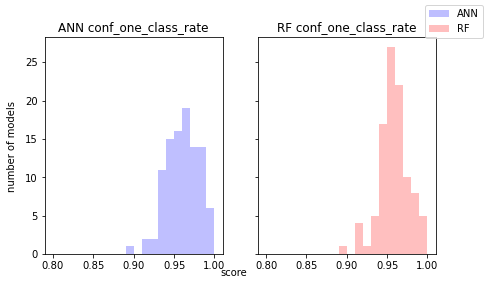

In [48]:
bins = np.linspace(0.8,1,20+1)
fig, axes = plt.subplots(1,2,figsize=(7,4),sharey = True,sharex=True)
axes[0].hist(dfANN['conf_one_class_rate'],alpha=0.25,bins=bins,color='b',label='ANN')
axes[0].set_title('ANN conf_one_class_rate')
axes[1].hist(dfRF['conf_one_class_rate'],alpha=0.25,bins=bins,color='r',label='RF')
axes[1].set_title('RF conf_one_class_rate')
c
fig.legend()
# fig.suptitle('Recall and Precision for Active compounds')
fig.text(0.06, 0.5, 'number of models', ha='center', va='center', rotation='vertical')
fig.text(0.5, 0.06, 'score', ha='center', va='center')

Text(0.5, 0.06, 'score')

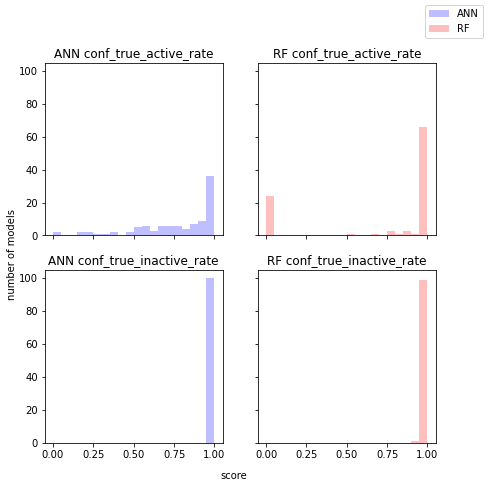

In [49]:
bins = np.linspace(0,1,20+1)
fig, axes = plt.subplots(2,2,figsize=(7,7),sharey = True,sharex=True)
axes[0,0].hist(dfANN['conf_true_active_rate'],alpha=0.25,bins=bins,color='b',label='ANN')
axes[0,0].set_title('ANN conf_true_active_rate')
axes[0,1].hist(dfRF['conf_true_active_rate'],alpha=0.25,bins=bins,color='r',label='RF')
axes[0,1].set_title('RF conf_true_active_rate')
axes[1,0].hist(dfANN['conf_true_inactive_rate'],alpha=0.25,bins=bins,color='b')
axes[1,0].set_title('ANN conf_true_inactive_rate')
axes[1,1].hist(dfRF['conf_true_inactive_rate'],alpha=0.25,bins=bins,color='r')
axes[1,1].set_title('RF conf_true_inactive_rate')
fig.legend()
# fig.suptitle('Recall and Precision for Active compounds')
fig.text(0.06, 0.5, 'number of models', ha='center', va='center', rotation='vertical')
fig.text(0.5, 0.06, 'score', ha='center', va='center')

In [55]:
# find the number of models where there is no compounds that are predicted to be 95% confident in active class only.
print('RF: ',sum(dfRF['conf_true_active_rate']==0))
print('ANN: ',sum(dfANN['conf_true_active_rate']==0))

RF:  24
ANN:  2


Definition of conf_true_active_rate: For compounds that are predicted to be 95% confident in active class only, the proportion of these compounds whose true label is "active" (+1).

We can see that RF alogrithm shows a bimodel distribution. For 70% of the models, if the conformal prediction predicts the compound to be active, then it is very likely (>95% accuracy) that the compounds is active.
However, for 20% of the models, the conf_true_active_rate is close to zero. One possible explaination is that the RF alogrithm cannot give a certain prediction of the compound activity, so there is no compounds that are predicted to be 95% confident in active class only.

## Weighted Accuracy and MCC

Text(0.5, 0.06, 'score')

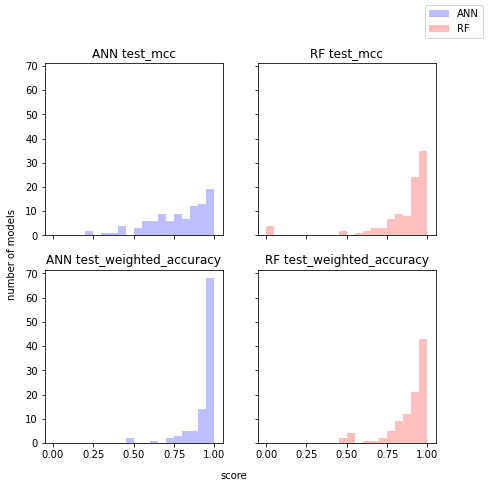

In [34]:
bins = np.linspace(0,1,20+1)
fig, axes = plt.subplots(2,2,figsize=(7,7),sharey = True,sharex=True)
axes[0,0].hist(dfANN['test_mcc'],alpha=0.25,bins=bins,color='b',label='ANN')
axes[0,0].set_title('ANN test_mcc')
axes[0,1].hist(dfRF['test_mcc'],alpha=0.25,bins=bins,color='r',label='RF')
axes[0,1].set_title('RF test_mcc')
axes[1,0].hist(dfANN['test_weighted_accuracy'],alpha=0.25,bins=bins,color='b')
axes[1,0].set_title('ANN test_weighted_accuracy')
axes[1,1].hist(dfRF['test_weighted_accuracy'],alpha=0.25,bins=bins,color='r')
axes[1,1].set_title('RF test_weighted_accuracy')
fig.legend()
# fig.suptitle('Recall and Precision for Active compounds')
fig.text(0.06, 0.5, 'number of models', ha='center', va='center', rotation='vertical')
fig.text(0.5, 0.06, 'score', ha='center', va='center')

 A coefficient of +1 represents a perfect prediction, 0 no better than random prediction and −1 indicates total disagreement between prediction and observation.

## Precision and recall

### Compare the means of recall and precision

In [36]:
dfMeanMetrics.index

Index(['test_roc', 'test_weighted_accuracy', 'test_mcc',
       'test_actives_precision', 'test_actives_recall', 'conf_one_class_rate',
       'conf_true_active_rate', 'conf_true_inactive_rate'],
      dtype='object')

In [37]:
lst = ['test_actives_precision', 'test_actives_recall']
dfMeanMetrics.loc[lst]

,ANN mean,ANN std,RF mean,RF std,change,p test,significant at p=0.05?,isANNBetter?,%improved models
test_actives_precision,0.67931,0.263105,0.937771,0.158927,-0.258461,2.538649e-14,True,False,2.0
test_actives_recall,0.89801,0.186138,0.795390,0.260755,0.102620,1.609249e-03,True,True,52.0


The ANN improves the recall for active compounds at the cost of decreasing the precision.

### Distribution of recall and precision for active compounds

Text(0.5, 0.06, 'score')

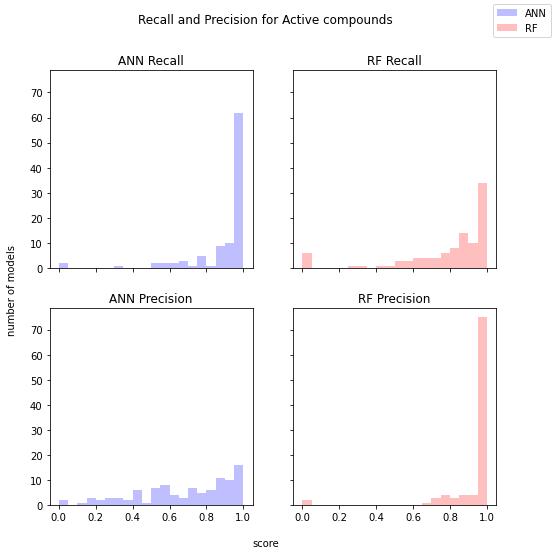

In [38]:
bins = np.linspace(0,1,20+1)
fig, axes = plt.subplots(2,2,figsize=(8,8),sharey = True,sharex=True)
axes[0,0].hist(dfANN['test_actives_recall'],alpha=0.25,bins=bins,color='b',label='ANN')
axes[0,0].set_title('ANN Recall')
axes[0,1].hist(dfRF['test_actives_recall'],alpha=0.25,bins=bins,color='r',label='RF')
axes[0,1].set_title('RF Recall')
axes[1,0].hist(dfANN['test_actives_precision'],alpha=0.25,bins=bins,color='b')
axes[1,0].set_title('ANN Precision')
axes[1,1].hist(dfRF['test_actives_precision'],alpha=0.25,bins=bins,color='r')
axes[1,1].set_title('RF Precision')
fig.legend()
fig.suptitle('Recall and Precision for Active compounds')
fig.text(0.06, 0.5, 'number of models', ha='center', va='center', rotation='vertical')
fig.text(0.5, 0.06, 'score', ha='center', va='center')

We see that the recall for active compounds have improved for ANN.
The precision is generally unaffected.

### Scatter plot of recall and precision for active compounds in ANN and RF

Text(0.5, 0.0, 'precision')

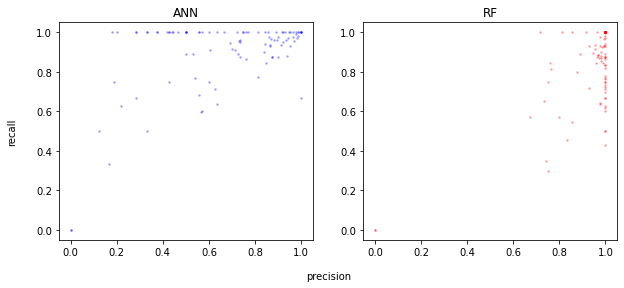

In [40]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,4))
ax1.scatter(x=dfANN['test_actives_precision'],y=dfANN['test_actives_recall'],
            c='b',alpha=0.25,s=2.5)
ax1.set_title('ANN')
ax2.scatter(x=dfRF['test_actives_precision'],y=dfRF['test_actives_recall'],
            c='r',alpha=0.25,s=2.5)
ax2.set_title('RF')
fig.text(0.06, 0.5, 'recall', ha='center', va='center', rotation='vertical')
fig.text(0.5,0.0,'precision',ha='center',va='center')

# dir(g)

Text(0.5, 0.0, 'precision')

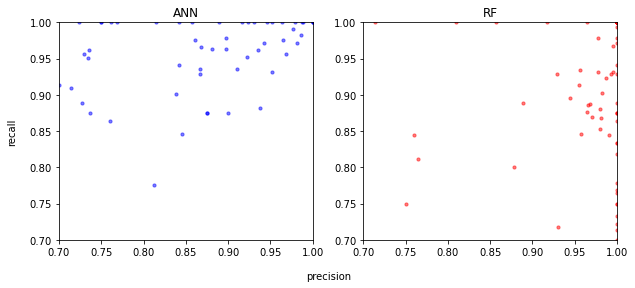

In [42]:
# an enlarged version
rang = [0.7,1.0]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,4))
ax1.scatter(x=dfANN['test_actives_precision'],y=dfANN['test_actives_recall'],
            c='b',alpha=0.5,s=10)
ax1.set_xlim(rang)
ax1.set_ylim(rang)
ax1.set_title('ANN')
ax2.scatter(x=dfRF['test_actives_precision'],y=dfRF['test_actives_recall'],
            c='r',alpha=0.5,s=10)
ax2.set_title('RF')
ax2.set_xlim(rang)
ax2.set_ylim(rang)
fig.text(0.06, 0.5, 'recall', ha='center', va='center', rotation='vertical')
fig.text(0.5,0.0,'precision',ha='center',va='center')

For ANN alogrithm, more models have higher recall for active compounds, but fewer models have higher precision.

# Pareto Front Analysis

## import data

In [27]:
import os
path = './ANN_results_0to99/'
lst  = os.listdir(path)
dfs = []
for l in lst:
    df = pd.read_csv(path+l,sep='\t')
    df['model_id']= l.split('compound')[0]
    dfs.append(df)
comANN = pd.concat(dfs,ignore_index=True)

path = './RF_results_0to99/'
lst  = os.listdir(path)
dfs = []
for l in lst:
    df = pd.read_csv(path+l,sep='\t')
    df['model_id']= l.split('compound')[0]
    dfs.append(df)
comRF = pd.concat(dfs,ignore_index=True)

comANN.set_index('model_id',inplace=True)
comRF.set_index('model_id',inplace=True)

In [28]:
comANN

,compound_id,?conf_inactive,?conf_active,true_labels,iprob,aprob,pred_labels
model_id,,,,,,,
P63316_10,0.0,0.0,1.0,1.0,0.233749,0.766251,1.0
P63316_10,1.0,1.0,0.0,1.0,0.991346,0.008654,0.0
P63316_10,2.0,1.0,1.0,1.0,0.490920,0.509080,1.0
P63316_10,3.0,0.0,1.0,1.0,0.152719,0.847281,1.0
P63316_10,4.0,1.0,1.0,1.0,0.351144,0.648856,1.0
...,...,...,...,...,...,...,...
Q9Y2R2_100,734.0,1.0,0.0,0.0,0.999155,0.000845,0.0
Q9Y2R2_100,735.0,1.0,0.0,0.0,0.999856,0.000144,0.0
Q9Y2R2_100,736.0,1.0,0.0,0.0,0.998175,0.001825,0.0


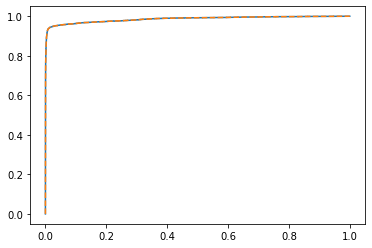

In [32]:
# use all the results
fpr, tpr, _ = roc_curve(comANN.loc[:,'true_labels'],comANN.loc[:,'aprob'])
plt.plot(fpr,tpr)
fpr, tpr, _ = roc_curve(comANN.loc[:,'true_labels'],comANN.loc[:,'aprob'])
plt.plot(fpr,tpr,ls='--')

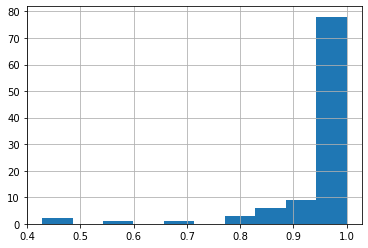

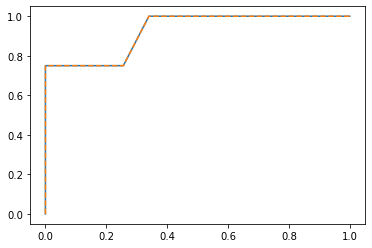

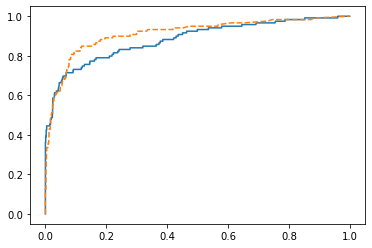

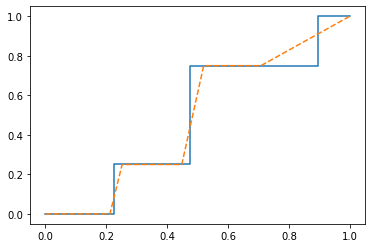

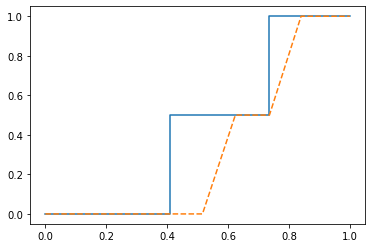

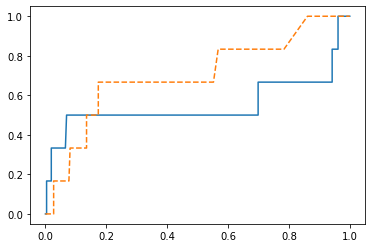

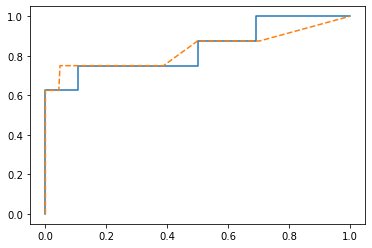

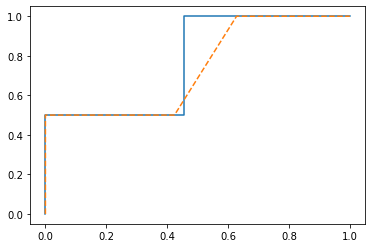

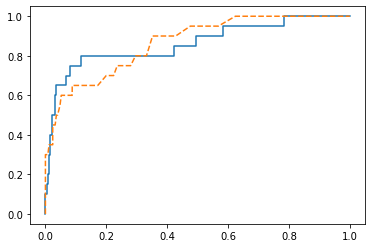

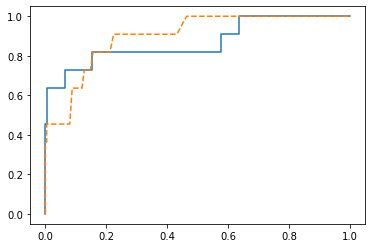

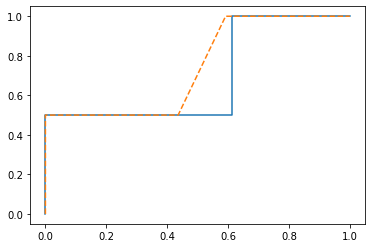

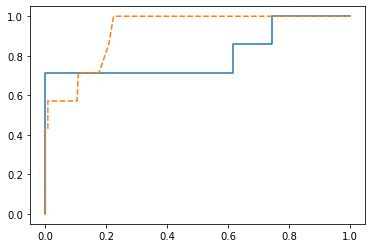

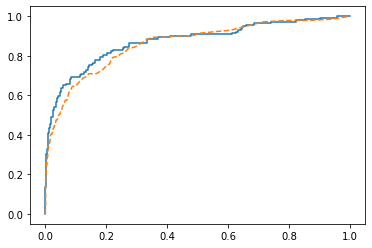

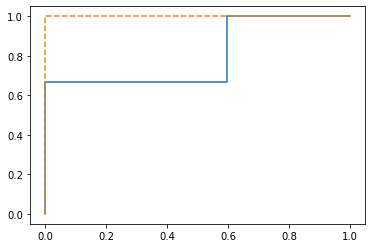

In [30]:
# select models that are poor in roc
dfANN['test_roc'].hist()
# so let's select model which have roc < 0.8
lst = dfANN[dfANN['test_roc']<0.9].index
# fig,axes =  plt.subplots(2,2,sharex=True,sharey=True)
for l in lst:
    from sklearn.metrics import roc_curve
    loc = l
    fig = plt.figure()
    fpr, tpr, _ = roc_curve(comANN.loc[loc,'true_labels'],comANN.loc[loc,'aprob'])
    plt.plot(fpr,tpr)
    fpr, tpr, _ = roc_curve(comRF.loc[loc,'true_labels'],comRF.loc[loc,'aprob'])
    plt.plot(fpr,tpr,linestyle='--')
    

The roc plot for each model is quite different.

There is no

## mcc and weighted_accuracy

In [77]:
# change the threshold, find the new mcc for each model.
# average the results
# for RF
from sklearn.metrics import matthews_corrcoef
tds = np.linspace(0,1,100+1)
lst = comRF.index.unique()
mcc_list = []
for t in tds:
    for l in lst:
        label = comRF.loc[l,'true_labels'].astype(int)
        probs = comRF.loc[l,'aprob']
        pred = (probs>t).astype(int)
        mcc = matthews_corrcoef(label.values,pred.values)
        mcc_list.append([t,mcc])
mccRF = pd.DataFrame(mcc_list)

# for ANN
tds = np.linspace(0,1,100+1)
lst = comANN.index.unique()
mcc_list = []
for t in tds:
    for l in lst:
        label = comANN.loc[l,'true_labels'].astype(int)
        probs = comANN.loc[l,'aprob']
        pred = (probs>t).astype(int)
        mcc = matthews_corrcoef(label.values,pred.values)
        mcc_list.append([t,mcc])
mccANN = pd.DataFrame(mcc_list)

# for accuracy
# for RF
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

tds = np.linspace(0,1,100+1)
lst = comRF.index.unique()
acc_list = []
for t in tds:
    for l in lst:
        label = comRF.loc[l,'true_labels'].astype(int)
        probs = comRF.loc[l,'aprob']
        pred = (probs>t).astype(int)
        sw = compute_sample_weight('balanced',label)
        acc = accuracy_score(label,pred,sample_weight=sw)
        acc_list.append([t,acc])
accRF = pd.DataFrame(acc_list)

# for ANN
tds = np.linspace(0,1,100+1)
lst = comANN.index.unique()
acc_list = []
for t in tds:
    for l in lst:
        label = comANN.loc[l,'true_labels'].astype(int)
        probs = comANN.loc[l,'aprob']
        pred = (probs>t).astype(int)
        sw = compute_sample_weight('balanced',label)
        acc = accuracy_score(label,pred,sample_weight=sw)
        acc_list.append([t,acc])
accANN = pd.DataFrame(acc_list)

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

...

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_y

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/sklearn/metrics/_classification.py:846: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


Text(0.5, 0, 'weighted accuracy')

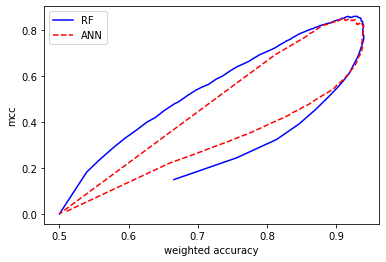

In [78]:
fig,ax = plt.subplots(1)
ax.plot(accRF.groupby(0).mean().values, mccRF.groupby(0).mean().values,c='b',
       label='RF')
ax.plot(accANN.groupby(0).mean().values, mccANN.groupby(0).mean().values,c='r',
       ls='--',label='ANN')
plt.legend()
plt.ylabel('mcc')
plt.xlabel('weighted accuracy')

<AxesSubplot:xlabel='0'>

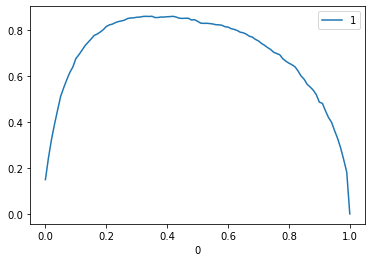

In [58]:
df.groupby(0).mean().plot()
# the plot shows that 0.35 is the optimal thershold.


## precision and recall

In [72]:
# change the threshold, find the new metric for each model.
# average the results
# for RF
from sklearn.metrics import confusion_matrix
tds = np.linspace(0,1,100+1)
lst = comRF.index.unique()
ap = []
ar = []
for t in tds:
    for l in lst:
        label = comRF.loc[l,'true_labels'].astype(int)
        probs = comRF.loc[l,'aprob']
        pred = (probs>t).astype(int)
        tn, fp, fn, tp = confusion_matrix(label, pred).ravel()
        actives_precision = tp/(tp+fp)
        actives_recall = tp/(tp+fn)
        ap.append([t,actives_precision])
        ar.append([t,actives_recall])
apRF = pd.DataFrame(ap)
arRF = pd.DataFrame(ar)

# for ANN
from sklearn.metrics import confusion_matrix
lst = comANN.index.unique()
ap = []
ar = []
for t in tds:
    for l in lst:
        label = comANN.loc[l,'true_labels'].astype(int)
        probs = comANN.loc[l,'aprob']
        pred = (probs>t).astype(int)
        tn, fp, fn, tp = confusion_matrix(label, pred).ravel()
        actives_precision = tp/(tp+fp)
        actives_recall = tp/(tp+fn)
        ap.append([t,actives_precision])
        ar.append([t,actives_recall])
apANN = pd.DataFrame(ap)
arANN = pd.DataFrame(ar)

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py

...

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in long_scalars
  from ipykernel import kernelapp as app
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars

/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars
/home/andy/miniconda3/envs/tf2/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in long_scalars

Text(0.5, 0, 'recall')

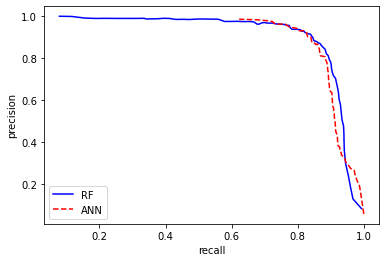

In [76]:
fig,ax = plt.subplots(1)
ax.plot(arRF.groupby(0).mean().values, apRF.groupby(0).mean().values,c='b',
       label='RF')
ax.plot(arANN.groupby(0).mean().values, apANN.groupby(0).mean().values,c='r',
       ls='--',label='ANN')
plt.legend()
plt.ylabel('precision')
plt.xlabel('recall')

In [ ]:
weighted accuracy

# Analysis about compounds

## import data

In [63]:
import os
path = './ANN_results_0to99/'
lst  = os.listdir(path)
dfs = []
for l in lst:
    df = pd.read_csv(path+l,sep='\t')
    dfs.append(df)
comANN = pd.concat(dfs,ignore_index=True)

path = './RF_results_0to99/'
lst  = os.listdir(path)
dfs = []
for l in lst:
    df = pd.read_csv(path+l,sep='\t')
    dfs.append(df)
comRF = pd.concat(dfs,ignore_index=True)

## Misclassification

### for active compounds

In [71]:
# for the RF
comRFActives = comRF[comRF['true_labels']==1]

# get misclassfied index
df = comRFActives[comRFActives['true_labels']!=comRFActives['pred_labels']].copy()
misClRF = list(df.index)

# get correctly classified index
df = comRFActives[comRFActives['true_labels']==comRFActives['pred_labels']].copy()
corClRF = list(df.index)
# percentage of active compounds being classified as inactive compounds 
print('For RF, percentage of active compounds being classified as inactive compounds: ',100*len(misClRF)/len(comRFActives))

For RF, percentage of active compounds being classified as inactive compounds:  11.708109458952892


In [72]:
# for the ANN
comANNActives = comANN[comANN['true_labels']==1]

# get misclassfied index
df = comANNActives[comANNActives['true_labels']!=comANNActives['pred_labels']].copy()
misClANN = list(df.index)

# get correctly classified index
df = comANNActives[comANNActives['true_labels']==comANNActives['pred_labels']].copy()
corClANN = list(df.index)
# percentage of active compounds being classified as inactive compounds 
print('For ANN, percentage of active compounds being classified as inactive compounds: ',100*len(misClANN)/len(comANNActives))

For ANN, percentage of active compounds being classified as inactive compounds:  6.222666500062477


In [73]:
# for active compounds which were misclassified by RF before
df = pd.concat((comRF.loc[misClRF,['aprob','pred_labels']],
           comANN.loc[misClRF,['aprob','pred_labels']]),axis=1)
df.columns = ['RF pred prob', 'RF pred label','ANN pred prob', 'ANN pred label', ]
df['corrected?']= (df['ANN pred label']==1)

# percentage of misclascsifications which have been corrected by ANN
print('proportion of misclassifications which have been corrected by ANN: ',
     sum(df['corrected?'])/len(df))

print('\n',df.head(3))

proportion of misclassifications which have been corrected by ANN:  0.5058697972251868

    RF pred prob  RF pred label  ANN pred prob  ANN pred label  corrected?
1      0.058333            0.0       0.008654             0.0       False
2      0.108333            0.0       0.509080             1.0        True
4      0.300000            0.0       0.648856             1.0        True


Explanation:

ANN shows a higher recall for active compounds. So it is not surprise that some actives compounds which were classified as inactive compounds by RF before, are now classified correctly by ANN. Although it comes at a cost of lower precision.

In [78]:
# for active compounds which were correctly classified by RF before
df = pd.concat((comRF.loc[corClRF,['aprob','pred_labels']],
           comANN.loc[corClRF,['aprob','pred_labels']]),axis=1)
df.columns = ['RF pred prob', 'RF pred label','ANN pred prob', 'ANN pred label', ]
df['misclassified?']= (df['ANN pred label']==0)

# percentage of correct predictions by RF which have been misclassified by ANN
print('proportion of corrected classification in RF which were misclassified by ANN: ',
     sum(df['misclassified?'])/len(df))
print('\n',df)

proportion of corrected classification in RF which were misclassified by ANN:  0.004953297480894424

        RF pred prob  RF pred label  ANN pred prob  ANN pred label  \
0          0.616667            1.0       0.766251             1.0   
3          0.575000            1.0       0.847281             1.0   
5          0.583333            1.0       0.396708             0.0   
10         0.716667            1.0       0.996732             1.0   
13         0.650000            1.0       0.975426             1.0   
...             ...            ...            ...             ...   
97403      0.538462            1.0       0.993961             1.0   
97406      0.792308            1.0       1.000000             1.0   
97409      1.000000            1.0       0.999999             1.0   
97414      0.700000            1.0       0.999994             1.0   
97416      1.000000            1.0       1.000000             1.0   

       misclassified?  
0               False  
3               False

Generally, the ANN improve active compounds prediction

### for inactive compounds

The recall for inactive compounds were high for both RF and ANN. So there is little to compare.

# Parameter choices

## import data

In [192]:
import os
os.chdir('/home/andy/pv4/pidgin_training/ANN_results_0to99/')

dfs = []
# averaged across 100 models
for file in os.listdir():
    df = pd.read_csv(file,sep='\t')
    dfs.append(df)
dfParam = pd.concat(dfs,axis=0).groupby(['num_layer','num_neuron']).mean().reset_index()
# dfParam = pd.read_csv('./ANN_results_0to99/B0BL08,SE_0.1parameter_search_results.csv',sep='\t')

In [195]:
dfParam

,num_layer,num_neuron,test_roc,test_prauc,test_bedroc,test_brier,accuracy,actives_precision,actives_recall,actives_f1,inactives_precision,inactives_recall,inactives_f1
0,1,10,0.96627,0.89857,0.92274,0.06796,0.922907,0.984568,0.849973,0.916411,0.891157,0.995841,0.935565
1,1,100,0.96461,0.89798,0.92177,0.07001,0.922947,0.984920,0.849619,0.921863,0.893379,0.996275,0.936540
2,1,1000,0.96434,0.89722,0.92097,0.07139,0.921436,0.985109,0.846544,0.920696,0.890413,0.996328,0.935014
3,3,10,0.96142,0.89529,0.92073,0.07096,0.922418,0.984880,0.848638,0.921711,0.892073,0.996198,0.935903
4,3,100,0.96362,0.89370,0.91874,0.07606,0.916063,0.984204,0.836222,0.913197,0.883374,0.995905,0.930665
5,3,1000,0.96513,0.89147,0.92302,0.07827,0.920056,0.983433,0.845445,0.912260,0.887925,0.994668,0.933167
6,5,10,0.95828,0.88133,0.90966,0.07987,0.913906,0.984896,0.831527,0.908357,0.882175,0.996284,0.929629
7,5,100,0.96253,0.89483,0.91903,0.07789,0.919716,0.984610,0.843672,0.918339,0.888177,0.995761,0.933499
8,5,1000,0.95751,0.86833,0.92989,0.07653,0.922153,0.981329,0.851765,0.919646,0.896321,0.992541,0.936069


In [194]:
dfParam.std(axis=0)

num_layer                1.732051
num_neuron             474.104419
test_roc                 0.003040
test_prauc               0.009954
test_bedroc              0.005288
test_brier               0.004271
accuracy                 0.003204
actives_precision        0.001195
actives_recall           0.006780
actives_f1               0.004747
inactives_precision      0.004571
inactives_recall         0.001233
inactives_f1             0.002475
dtype: float64

The results are very insensitive to the parameter choices.

## Effect on actives_f1

num_neuron      10        100       1000
num_layer                               
1           0.916411  0.921863  0.920696
3           0.921711  0.913197  0.912260
5           0.908357  0.918339  0.919646


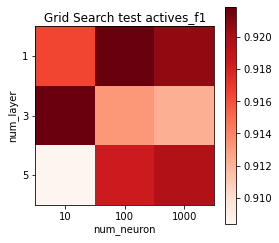

In [189]:
columns = ['num_layer','num_neuron','actives_f1']
df = dfParam[columns].pivot(index=columns[0], columns=columns[1], values=columns[-1])
print(df)
import matplotlib

fig,ax = plt.subplots(1,1,figsize=(4,4))
#norm = matplotlib.colors.Normalize(vmin=0, vmax=1, clip=False)
plt.imshow(df.values, interpolation='nearest', cmap=matplotlib.cm.Reds,
          )
plt.xlabel(columns[1])
plt.ylabel(columns[0])
plt.xticks(ticks = np.arange(df.shape[1]),labels=list(df.columns))
plt.yticks(ticks =np.arange(df.shape[0]),labels=list(df.index))
plt.colorbar()
plt.title('Grid Search test {}'.format(columns[-1]))
plt.show()

## Effect on inactives F1

num_neuron      10        100       1000
num_layer                               
1           0.935565  0.936540  0.935014
3           0.935903  0.930665  0.933167
5           0.929629  0.933499  0.936069


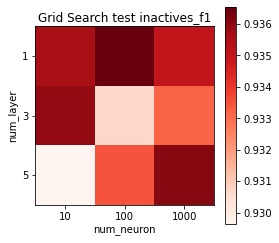

In [190]:
columns = ['num_layer','num_neuron','inactives_f1']
df = dfParam[columns].pivot(index=columns[0], columns=columns[1], values=columns[-1])
print(df)
import matplotlib

fig,ax = plt.subplots(1,1,figsize=(4,4))
#norm = matplotlib.colors.Normalize(vmin=0, vmax=1, clip=False)
plt.imshow(df.values, interpolation='nearest', cmap=matplotlib.cm.Reds,
          )
plt.xlabel(columns[1])
plt.ylabel(columns[0])
plt.xticks(ticks = np.arange(df.shape[1]),labels=list(df.columns))
plt.yticks(ticks =np.arange(df.shape[0]),labels=list(df.index))
plt.colorbar()
plt.title('Grid Search test {}'.format(columns[-1]))
plt.show()

virtually no effect on parameter choices

## Correlation table

<AxesSubplot:>

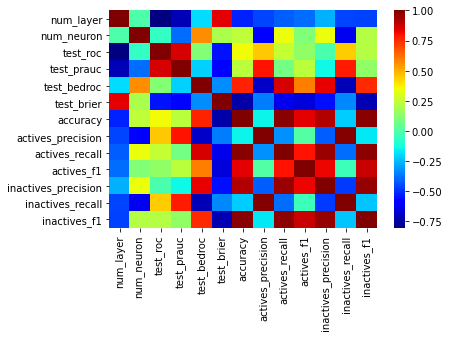

In [191]:
import matplotlib
import seaborn as sns
sns.heatmap(dfParam.corr(),cmap='jet')
# blank if it is nan

increase the number of layers is not a good idea. (blue mainly)

increase the number of neurons will decrease the inactives_recall and actives_precision.

Suggestion: Use a simple ANN?